# Lab 6

You are tasked with evaluating card counting strategies for black jack. In order to do so, you will use object oriented programming to create a playable casino style black jack game where a computer dealer plays against $n$ computer players and possibily one human player. If you don't know the rules of blackjack or card counting, please google it. 

A few requirements:
* The game should utilize multiple 52-card decks. Typically the game is played with 6 decks.
* Players should have chips.
* Dealer's actions are predefined by rules of the game (typically hit on 16). 
* The players should be aware of all shown cards so that they can count cards.
* Each player could have a different strategy.
* The system should allow you to play large numbers of games, study the outcomes, and compare average winnings per hand rate for different strategies.

1. Begin by creating a classes to represent cards and decks. The deck should support more than one 52-card set. The deck should allow you to shuffle and draw cards. Include a "plastic" card, placed randomly in the deck. Later, when the plastic card is dealt, shuffle the cards before the next deal.

In [94]:
import random

# The base class that handles logging/messaging for all other classes
class base:
    SILENT   = 6
    DEBUG    = 1
    INFO     = 2
    WARNING  = 3
    ERROR    = 4
    CRITICAL = 5

    def __init__(self, level=0):
        self.level = level

    # Prints a message only if it meets the minimum level threshold
    def message(self, level, *args):
        if level >= self.level:
            print(*args)


# The Card class that represents a single playing card
class Card(base):
    __suits  = ["Clubs", "Diamonds", "Hearts", "Spades"]
    __values = list(range(2, 11)) + ["Jack", "Queen", "King", "Ace"]

    def __init__(self, suit, value=None):
        base.__init__(self)
        # Make sure the suit and value are valid, otherwise set to None
        self.__suit  = suit if suit in self.__suits + ["ShuffleCard"] else None
        self.__value = value if value in self.__values else None

        if self.__suit is None:
            self.message(self.ERROR, "Error, bad suit:", suit)
        if self.__value is None and self.__suit != "ShuffleCard":
            self.message(self.ERROR, "Error, bad value:", value)

    def value(self):
        return self.__value

    def suit(self):
        return self.__suit

    # Returns the blackjack numerical value of the card
    def numerical_value(self):
        if self.__value == "Ace":
            return 1
        elif self.__value in ["Jack", "Queen", "King"]:
            return 10
        else:
            return self.__value

    # Returns true if this card is the plastic shuffle card
    def shuffle_card(self):
        return self.__suit == "ShuffleCard"

    def __repr__(self):
        if self.shuffle_card():
            return "ShuffleCard"
        return "{} of {}".format(self.__value, self.__suit)


# The Deck class that holds and manages all the cards
class Deck(base):
    __suits  = ["Clubs", "Diamonds", "Hearts", "Spades"]
    __values = list(range(2, 11)) + ["Jack", "Queen", "King", "Ace"]

    def __init__(self, n_decks=6):
        base.__init__(self)
        self.__n_decks = n_decks
        self.__cards   = list()
        self.__build()

    # Builds a single 52 card deck
    def __make_deck(self):
        deck = list()
        for suit in self.__suits:
            for value in self.__values:
                deck.append(Card(suit, value))
        return deck

    # Builds the full multi-deck shoe, shuffles it, and places the shuffle card somewhere in the back half
    def __build(self):
        self.__cards = list()
        for _ in range(self.__n_decks):
            self.__cards.extend(self.__make_deck())
        self.shuffle()
        shuffle_pos = random.randint(len(self.__cards)//2, len(self.__cards)-1)
        self.__cards.insert(shuffle_pos, Card("ShuffleCard"))

    # Shuffles the cards
    def shuffle(self):
        random.shuffle(self.__cards)

    # Deals a card from the top of the deck, and rebuilds the deck if the shuffle card is hit
    def deal(self):
        card = self.__cards.pop()
        if card.shuffle_card():
            self.__build()
            card = self.__cards.pop()
        return card

    def cards_remaining(self):
        return len(self.__cards)

In [95]:
deck = Deck()

print("Cards remaining:", deck.cards_remaining())

cards = [deck.deal() for _ in range(10)]
for card in cards:
    print(card)

print("Numerical values:", [c.numerical_value() for c in cards])
print("Cards remaining:", deck.cards_remaining())

Cards remaining: 313
King of Clubs
Queen of Hearts
Jack of Clubs
Jack of Diamonds
Jack of Spades
10 of Clubs
7 of Spades
Queen of Hearts
8 of Hearts
9 of Hearts
Numerical values: [10, 10, 10, 10, 10, 10, 7, 10, 8, 9]
Cards remaining: 303


2. Now design your game on a UML diagram. You may want to create classes to represent, players, a hand, and/or the game. As you work through the lab, update your UML diagram. At the end of the lab, submit your diagram (as pdf file) along with your notebook. 

3. Begin with implementing the skeleton (ie define data members and methods/functions, but do not code the logic) of the classes in your UML diagram.

In [96]:
# The PlayerBase class that serves as the foundation for all players at the table
class PlayerBase(base):
    def __init__(self, name, chips):
        base.__init__(self)
        self.__name  = name
        self.__chips = chips

    # Returns the player's name
    def name(self):
        pass

    # Returns how many chips the player has
    def chips(self):
        pass

    # Adds chips to the player's total
    def pay(self, amount):
        pass

    # Removes chips from the player's total
    def deduct(self, amount):
        pass

    # Decides whether to hit or stay - each player type will implement this differently
    def play_hand(self, down_card, up_cards, seen_cards):
        pass

    def __str__(self):
        return self.__name + " (" + str(self.__chips) + " chips)"

    __repr__ = __str__


# The DealerPlayer class that follows the standard casino dealer rules
class DealerPlayer(PlayerBase):
    def __init__(self, threshold=16):
        PlayerBase.__init__(self, "Mr. Dealer", 1000)
        self.__threshold = threshold

    # Hits if hand value is below the threshold, stays otherwise
    def play_hand(self, down_card, up_cards, seen_cards):
        pass


# The ConsolePlayer class that lets a human type in their decisions
class ConsolePlayer(PlayerBase):
    def __init__(self, name, chips):
        PlayerBase.__init__(self, name, chips)

    # Shows the cards to the human and waits for their input
    def play_hand(self, down_card, up_cards, seen_cards):
        pass


# The Game class that manages the table, players, deck, and runs the hands
class Game(base):
    def __init__(self, n_decks=6):
        base.__init__(self)
        self.__n_decks     = n_decks
        self.__players     = list()
        self.__all_players = list()
        self.__shuffle     = False

    # Returns the list of active players
    def players(self):
        pass

    # Returns the list of all players including eliminated ones
    def all_players(self):
        pass

    # Adds a player to the game
    def add_player(self, player):
        pass

    # Deals a card and flags if the shuffle card was hit
    def deal_and_check_shuffle(self, deck):
        pass

    # Prints out the current state of the table
    def show_status(self, hands, seen_cards):
        pass

    # Plays a set number of hands from start to finish
    def play(self, n_hands):
        pass

In [97]:
dealer = DealerPlayer()
human  = ConsolePlayer("John", 100)
game   = Game()

print(dealer)
print(human)
print(game.__class__.__name__)

Mr. Dealer (1000 chips)
John (100 chips)
Game


4. Complete the implementation by coding the logic of all functions. For now, just implement the dealer player and human player.

In [98]:
# A helper function that calculates the total value of a hand, handling aces correctly
def calc_hand_value(cards):
    total = 0
    aces  = 0
    for card in cards:
        total += card.numerical_value()
        if card.value() == "Ace":
            aces += 1
    # Try to count one ace as 11 instead of 1 if it doesn't bust us
    while aces > 0 and total + 10 <= 21:
        total += 10
        aces  -= 1
    return total


# The PlayerBase class that serves as the foundation for all players at the table
class PlayerBase(base):
    def __init__(self, name, chips):
        base.__init__(self)
        self.__name  = name
        self.__chips = chips

    def name(self):
        return self.__name

    def chips(self):
        return self.__chips

    # Adds chips to the player's total
    def pay(self, amount):
        self.__chips += amount

    # Removes chips from the player's total
    def deduct(self, amount):
        self.__chips -= amount

    # Decides whether to hit or stay - each player type will implement this differently
    def play_hand(self, down_card, up_cards, seen_cards):
        raise NotImplementedError

    def __str__(self):
        return self.__name + " (" + str(self.__chips) + " chips)"

    __repr__ = __str__


# The DealerPlayer class that follows standard casino dealer rules
class DealerPlayer(PlayerBase):
    def __init__(self, name="Mr. Dealer", threshold=16, chips=1000):
        PlayerBase.__init__(self, name, chips)
        self.__threshold = threshold

    # Hits if the hand value is below the threshold, stays otherwise
    def play_hand(self, down_card, up_cards, seen_cards):
        hand_value = calc_hand_value([down_card] + up_cards)
        return hand_value < self.__threshold


# The ConsolePlayer class that lets a human type in their decisions
class ConsolePlayer(PlayerBase):
    def __init__(self, name, chips):
        PlayerBase.__init__(self, name, chips)

    # Shows the cards to the human and waits for their input
    def play_hand(self, down_card, up_cards, seen_cards):
        print("Down Card:", down_card)
        print("Up Cards:", up_cards)
        print("Seen Cards:", seen_cards)
        hit_str = input("Hit (Y/N):")
        return hit_str.upper() == "Y"


# The Game class that manages the table, players, deck, and runs the hands
class Game(base):
    def __init__(self, n_decks=6):
        base.__init__(self)
        self.__n_decks     = n_decks
        self.__players     = list()
        self.__all_players = list()
        self.__shuffle     = False

    def players(self):
        return self.__players

    def all_players(self):
        return self.__all_players

    # Adds a player to the game
    def add_player(self, player):
        self.__players.append(player)
        self.__all_players.append(player)

    # Deals a card and flags if the shuffle card was hit
    def deal_and_check_shuffle(self, deck):
        card = deck.deal()
        if card.shuffle_card():
            self.__shuffle = True
            card = deck.deal()
        return card

    # Prints out the current state of the table
    def show_status(self, hands, seen_cards):
        self.message(self.INFO, "-" * 50)
        self.message(self.INFO, "Hands:", hands)
        self.message(self.INFO, "Seen Cards:", seen_cards)
        self.message(self.INFO, "*" * 50)
        self.message(self.INFO, "Players:")
        for i, player in enumerate(self.__all_players):
            self.message(self.INFO, "  Player", i, ":", player)

    # Plays a set number of hands from start to finish
    def play(self, n_hands):
        deck = Deck(self.__n_decks)
        deck.shuffle()

        for i_hand in range(n_hands):

            # Remove players with no chips
            self.__players = list(filter(lambda p: p.chips() >= 1, self.__players))
            self.message(self.DEBUG, "Starting Hand:", i_hand+1, "/", n_hands)

            # Rebuild deck if shuffle card was hit last hand
            if self.__shuffle:
                self.message(self.DEBUG, "Reshuffling deck.")
                deck = Deck(self.__n_decks)
                deck.shuffle()
                self.__shuffle = False

            seen_cards = list()
            hands      = list()

            # Deal each player their down card and one up card
            for player in self.__players:
                down_card = self.deal_and_check_shuffle(deck)
                up_cards  = [self.deal_and_check_shuffle(deck)]
                hands.append((down_card, up_cards))
                # Dealer's down card stays hidden, everyone else's is visible
                if player != self.__players[-1]:
                    seen_cards.append(down_card)
                seen_cards.extend(up_cards)

            self.show_status(hands, seen_cards)

            # Each player takes their turn hitting or staying
            hand_values = list()
            for player, (down_card, up_cards) in zip(self.__players, hands):
                while player.play_hand(down_card, up_cards, seen_cards):
                    new_card = self.deal_and_check_shuffle(deck)
                    up_cards.append(new_card)
                    seen_cards.append(new_card)
                    if calc_hand_value([down_card] + up_cards) > 21:
                        break
                hand_values.append(calc_hand_value([down_card] + up_cards))

            # Pay out chips based on results
            dealer_value = hand_values[-1]
            self.message(self.DEBUG, "Dealer hand is:", dealer_value)

            if dealer_value > 21:
                # Dealer busted - everyone still standing wins
                self.message(self.DEBUG, "Dealer busted!")
                for player, hand_value in zip(self.__players[:-1], hand_values[:-1]):
                    if hand_value > 21:
                        player.deduct(1)
                    elif hand_value == 21:
                        player.pay(2)
                    else:
                        player.pay(1)
            else:
                # Compare each player's hand to the dealer
                for player, hand_value in zip(self.__players[:-1], hand_values[:-1]):
                    if hand_value > 21:
                        player.deduct(1)
                    elif hand_value == 21:
                        player.pay(2)
                    elif hand_value > dealer_value:
                        player.pay(1)
                    elif hand_value == dealer_value:
                        pass
                    else:
                        player.deduct(1)

In [99]:
game = Game()
game.level = game.DEBUG

dealer  = DealerPlayer()
player1 = DealerPlayer(name="Player 1", chips=100)
player2 = DealerPlayer(name="Player 2", chips=100)

game.add_player(player1)
game.add_player(player2)
game.add_player(dealer)

game.play(3)

print("Final chip counts:")
print(player1)
print(player2)
print(dealer)

Starting Hand: 1 / 3
--------------------------------------------------
Hands: [(Queen of Hearts, [10 of Diamonds]), (9 of Diamonds, [3 of Hearts]), (King of Hearts, [Ace of Spades])]
Seen Cards: [Queen of Hearts, 10 of Diamonds, 9 of Diamonds, 3 of Hearts, Ace of Spades]
**************************************************
Players:
  Player 0 : Player 1 (100 chips)
  Player 1 : Player 2 (100 chips)
  Player 2 : Mr. Dealer (1000 chips)
Dealer hand is: 21
Starting Hand: 2 / 3
--------------------------------------------------
Hands: [(2 of Clubs, [3 of Diamonds]), (10 of Spades, [Queen of Spades]), (7 of Spades, [Queen of Clubs])]
Seen Cards: [2 of Clubs, 3 of Diamonds, 10 of Spades, Queen of Spades, Queen of Clubs]
**************************************************
Players:
  Player 0 : Player 1 (99 chips)
  Player 1 : Player 2 (99 chips)
  Player 2 : Mr. Dealer (1000 chips)
Dealer hand is: 17
Starting Hand: 3 / 3
--------------------------------------------------
Hands: [(Ace of Clubs, 

5.  Test. Demonstrate game play. For example, create a game of several dealer players and show that the game is functional through several rounds.

In [100]:
# Set up the game with INFO level so we can see the hands being played
game = Game()
game.level = game.INFO

# Create the dealer and three players all starting with 100 chips
dealer  = DealerPlayer()
player1 = DealerPlayer(name="Player 1", chips=100)
player2 = DealerPlayer(name="Player 2", chips=100)
player3 = DealerPlayer(name="Player 3", chips=100)

# Add all players to the game, dealer goes last
game.add_player(player1)
game.add_player(player2)
game.add_player(player3)
game.add_player(dealer)

# Play 5 rounds and show the results
game.play(5)

# Print the final chip counts for each player
print("Final chip counts:")
print(player1)
print(player2)
print(player3)
print(dealer)

--------------------------------------------------
Hands: [(2 of Clubs, [9 of Clubs]), (10 of Diamonds, [3 of Spades]), (Queen of Hearts, [Ace of Hearts]), (10 of Hearts, [6 of Diamonds])]
Seen Cards: [2 of Clubs, 9 of Clubs, 10 of Diamonds, 3 of Spades, Queen of Hearts, Ace of Hearts, 6 of Diamonds]
**************************************************
Players:
  Player 0 : Player 1 (100 chips)
  Player 1 : Player 2 (100 chips)
  Player 2 : Player 3 (100 chips)
  Player 3 : Mr. Dealer (1000 chips)
--------------------------------------------------
Hands: [(10 of Clubs, [Jack of Spades]), (3 of Diamonds, [6 of Hearts]), (6 of Diamonds, [9 of Hearts]), (2 of Hearts, [7 of Clubs])]
Seen Cards: [10 of Clubs, Jack of Spades, 3 of Diamonds, 6 of Hearts, 6 of Diamonds, 9 of Hearts, 7 of Clubs]
**************************************************
Players:
  Player 0 : Player 1 (101 chips)
  Player 1 : Player 2 (99 chips)
  Player 2 : Player 3 (102 chips)
  Player 3 : Mr. Dealer (1000 chips)
------

6. Implement a new player with the following strategy:

    * Assign each card a value: 
        * Cards 2 to 6 are +1 
        * Cards 7 to 9 are 0 
        * Cards 10 through Ace are -1
    * Compute the sum of the values for all cards seen so far.
    * Hit if sum is very negative, stay if sum is very positive. Select a threshold for hit/stay, e.g. 0 or -2.  

In [101]:
# The CardCountingPlayer class that uses the hi-lo card counting strategy
class CardCountingPlayer(PlayerBase):
    def __init__(self, name, chips, threshold=0):
        PlayerBase.__init__(self, name, chips)
        self.__threshold = threshold

    # Assigns a counting value to each card based on the hi-lo strategy
    def count_value(self, card):
        v = card.numerical_value()
        if v >= 2 and v <= 6:
            return 1
        elif v >= 7 and v <= 9:
            return 0
        else:
            return -1

    # Hits if the running count is below the threshold and hand is below 17, stays otherwise
    def play_hand(self, down_card, up_cards, seen_cards):
        hand_value = calc_hand_value([down_card] + up_cards)
        # Never hit on 17 or above regardless of count
        if hand_value >= 17:
            return False
        count = sum(self.count_value(card) for card in seen_cards)
        return count < self.__threshold

In [102]:
game = Game()
game.level = game.SILENT

dealer  = DealerPlayer()
counter = CardCountingPlayer("Counter", chips=100, threshold=0)
player1 = DealerPlayer(name="Player 1", chips=100)
player2 = DealerPlayer(name="Player 2", chips=100)

game.add_player(counter)
game.add_player(player1)
game.add_player(player2)
game.add_player(dealer)

game.play(5)

print("Final chip counts:")
print(counter)
print(player1)
print(player2)
print(dealer)

Final chip counts:
Counter (98 chips)
Player 1 (101 chips)
Player 2 (104 chips)
Mr. Dealer (1000 chips)


7. Create a test scenario where one player, using the above strategy, is playing with a dealer and 3 other players that follow the dealer's strategy. Each player starts with same number of chips. Play 50 rounds (or until the strategy player is out of money). Compute the strategy player's winnings. You may remove unnecessary printouts from your code (perhaps implement a verbose/quiet mode) to reduce the output.

In [103]:
game = Game()
game.level = game.SILENT

counter = CardCountingPlayer("Counter", chips=100, threshold=0)
player1 = DealerPlayer(name="Player 1", chips=100)
player2 = DealerPlayer(name="Player 2", chips=100)
player3 = DealerPlayer(name="Player 3", chips=100)
dealer  = DealerPlayer()

game.add_player(counter)
game.add_player(player1)
game.add_player(player2)
game.add_player(player3)
game.add_player(dealer)

game.play(50)

# Print a clean summary of the results
print("=" * 40)
print("Final Results After 50 Rounds:")
print("=" * 40)
for player in game.all_players():
    print(player)

winnings = counter.chips() - 100
print("\nCounter Winnings:", winnings)
print("Average per round:", round(winnings / 50, 2))

Final Results After 50 Rounds:
Counter (116 chips)
Player 1 (120 chips)
Player 2 (120 chips)
Player 3 (113 chips)
Mr. Dealer (1000 chips)

Counter Winnings: 16
Average per round: 0.32


8. Create a loop that runs 100 games of 50 rounds, as setup in previous question, and store the strategy player's chips at the end of the game (aka "winnings") in a list. Histogram the winnings. What is the average winnings per round? What is the standard deviation. What is the probabilty of net winning or lossing after 50 rounds?


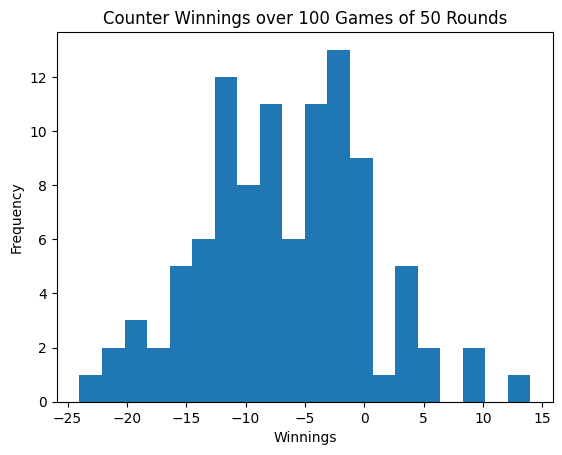

Results over 100 Games of 50 Rounds:
Average winnings per game: -6.78
Average winnings per round: -0.14
Standard deviation: 7.03
Probability of net winning: 0.11
Probability of net losing: 0.86


In [104]:
import numpy as np
import matplotlib.pyplot as plt

starting_chips = 100
winnings = list()

# Run 100 games of 50 rounds each and store the counter's winnings
for _ in range(100):
    game = Game()
    game.level = game.SILENT

    counter = CardCountingPlayer("Counter", chips=starting_chips, threshold=0)
    player1 = DealerPlayer(name="Player 1", chips=starting_chips)
    player2 = DealerPlayer(name="Player 2", chips=starting_chips)
    player3 = DealerPlayer(name="Player 3", chips=starting_chips)
    dealer  = DealerPlayer()

    game.add_player(counter)
    game.add_player(player1)
    game.add_player(player2)
    game.add_player(player3)
    game.add_player(dealer)

    game.play(50)

    winnings.append(counter.chips() - starting_chips)

# Plot a histogram of the winnings across all 100 games
plt.hist(winnings, bins=20)
plt.xlabel("Winnings")
plt.ylabel("Frequency")
plt.title("Counter Winnings over 100 Games of 50 Rounds")
plt.show()

# Print out the key statistics
print("=" * 40)
print("Results over 100 Games of 50 Rounds:")
print("=" * 40)
print("Average winnings per game:", round(np.mean(winnings), 2))
print("Average winnings per round:", round(np.mean(winnings) / 50, 2))
print("Standard deviation:", round(np.std(winnings), 2))
print("Probability of net winning:", sum(w > 0 for w in winnings) / 100)
print("Probability of net losing:", sum(w < 0 for w in winnings) / 100)

9. Repeat previous questions scanning the value of the threshold. Try at least 5 different threshold values. Can you find an optimal value?

Threshold: -4
Average winnings per game: -10.24
Average winnings per round: -0.2
Standard deviation: 6.97
Probability of net winning: 0.06
Probability of net losing: 0.92

Threshold: -2
Average winnings per game: -10.5
Average winnings per round: -0.21
Standard deviation: 6.76
Probability of net winning: 0.05
Probability of net losing: 0.93

Threshold: 0
Average winnings per game: -5.81
Average winnings per round: -0.12
Standard deviation: 7.23
Probability of net winning: 0.2
Probability of net losing: 0.8

Threshold: 2
Average winnings per game: -1.41
Average winnings per round: -0.03
Standard deviation: 7.44
Probability of net winning: 0.41
Probability of net losing: 0.55

Threshold: 4
Average winnings per game: 2.85
Average winnings per round: 0.06
Standard deviation: 8.55
Probability of net winning: 0.61
Probability of net losing: 0.35



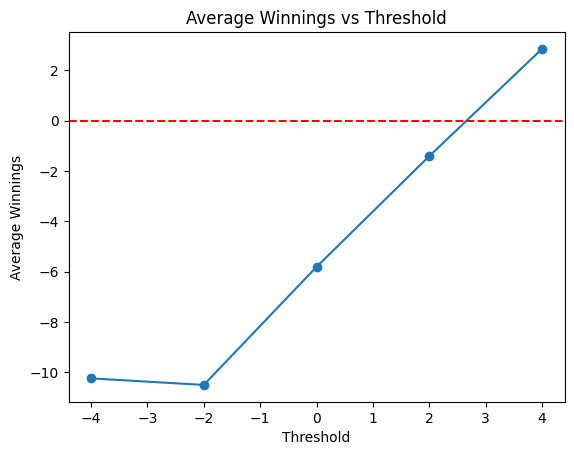

Optimal threshold: 4


In [105]:
starting_chips = 100
thresholds = [-4, -2, 0, 2, 4]
avg_winnings = list()

# Run 100 games of 50 rounds for each threshold value
for threshold in thresholds:
    winnings = list()
    
    for _ in range(100):
        game = Game()
        game.level = game.SILENT

        counter = CardCountingPlayer("Counter", chips=starting_chips, threshold=threshold)
        player1 = DealerPlayer(name="Player 1", chips=starting_chips)
        player2 = DealerPlayer(name="Player 2", chips=starting_chips)
        player3 = DealerPlayer(name="Player 3", chips=starting_chips)
        dealer  = DealerPlayer()

        game.add_player(counter)
        game.add_player(player1)
        game.add_player(player2)
        game.add_player(player3)
        game.add_player(dealer)

        game.play(50)
        winnings.append(counter.chips() - starting_chips)

    avg_winnings.append(np.mean(winnings))

    # Print results for each threshold
    print("=" * 40)
    print("Threshold:", threshold)
    print("=" * 40)
    print("Average winnings per game:", round(np.mean(winnings), 2))
    print("Average winnings per round:", round(np.mean(winnings) / 50, 2))
    print("Standard deviation:", round(np.std(winnings), 2))
    print("Probability of net winning:", sum(w > 0 for w in winnings) / 100)
    print("Probability of net losing:", sum(w < 0 for w in winnings) / 100)
    print()

# Plot average winnings for each threshold to find the optimal value
plt.plot(thresholds, avg_winnings, marker="o")
plt.xlabel("Threshold")
plt.ylabel("Average Winnings")
plt.title("Average Winnings vs Threshold")
plt.axhline(y=0, color="r", linestyle="--")
plt.show()

# Print the optimal threshold
best_threshold = thresholds[np.argmax(avg_winnings)]
print("Optimal threshold:", best_threshold)

10. Create a new strategy based on web searches or your own ideas. Demonstrate that the new strategy will result in increased or decreased winnings. 

Testing Card Counting Strategy...
  Average: 3.19

Testing Basic Strategy...
  Average: 0.66

Strategy Comparison:
Card Counting (threshold=4 (optimal threshold)): 3.19
Basic Strategy:              0.66

Card Counting had better performance


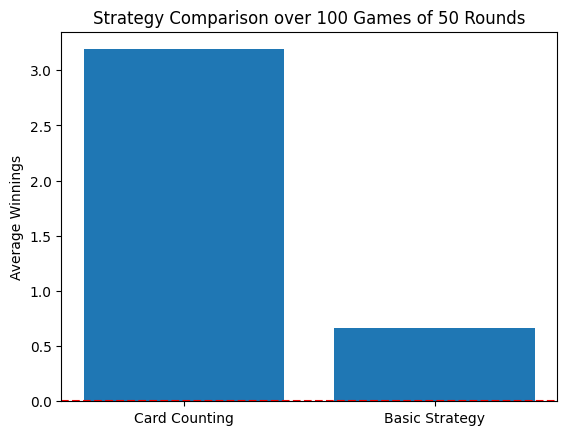

In [113]:
# A new strategy that considers both the dealer's up card and the player's hand value
class BasicStrategyPlayer(PlayerBase):
    def __init__(self, chips=100):
        PlayerBase.__init__(self, "Basic Strategy Player", chips)

    # Decides whether to hit based on player hand and dealer's visible card
    def play_hand(self, down_card, up_cards, seen_cards):
        hand_value = calc_hand_value([down_card] + up_cards)
        dealer_up  = up_cards[0].numerical_value()

        if hand_value >= 17:
            return False
        if hand_value <= 8:
            return True
        if 13 <= hand_value <= 16:
            return dealer_up > 6
        if hand_value == 12:
            return dealer_up < 4 or dealer_up > 6
        return True


# Test card counting strategy
print("Testing Card Counting Strategy...")
winnings_counter = list()
for _ in range(100):
    game = Game()
    game.level = game.SILENT

    game.add_player(CardCountingPlayer("Counter", chips=100, threshold=4))
    game.add_player(DealerPlayer(name="Player 1", chips=100))
    game.add_player(DealerPlayer(name="Player 2", chips=100))
    game.add_player(DealerPlayer(name="Player 3", chips=100))
    game.add_player(DealerPlayer())

    game.play(50)

    winnings_counter.append(game.all_players()[0].chips() - 100)

avg_counter = np.mean(winnings_counter)
print(f"  Average: {avg_counter:.2f}")


# Test basic strategy
print("\nTesting Basic Strategy...")
winnings_basic = list()
for _ in range(100):
    game = Game()
    game.level = game.SILENT

    game.add_player(BasicStrategyPlayer(chips=100))
    game.add_player(DealerPlayer(name="Player 1", chips=100))
    game.add_player(DealerPlayer(name="Player 2", chips=100))
    game.add_player(DealerPlayer(name="Player 3", chips=100))
    game.add_player(DealerPlayer())

    game.play(50)

    winnings_basic.append(game.all_players()[0].chips() - 100)

avg_basic = np.mean(winnings_basic)
print(f"  Average: {avg_basic:.2f}")


# Compare the two strategies
print("\n" + "=" * 40)
print("Strategy Comparison:")
print("=" * 40)
print(f"Card Counting (threshold=4 (optimal threshold)): {avg_counter:.2f}")
print(f"Basic Strategy:              {avg_basic:.2f}")

if avg_counter > avg_basic:
    print("\nCard Counting had better performance")
elif avg_basic > avg_counter:
    print("\nBasic Strategy had better performance!")
else:
    print("\nBoth strategies tied!")

# Bar chart comparing the two strategies
plt.bar(["Card Counting", "Basic Strategy"], [avg_counter, avg_basic])
plt.ylabel("Average Winnings")
plt.title("Strategy Comparison over 100 Games of 50 Rounds")
plt.axhline(y=0, color="r", linestyle="--")
plt.show()